# UT2 · 3 — Matplotlib en profundidad

Tercer cuaderno de la Unidad 2. Aquí nos centramos en **Matplotlib**: los tipos de gráfica más habituales para explorar datos, cómo personalizarlas, y cómo dar el salto directo desde un DataFrame de Pandas a una gráfica.

Es autocontenido: regenera el mismo dataset de jugadores que en el cuaderno de Pandas (misma semilla aleatoria, así que los números coinciden).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Regeneramos el mismo dataset que en UT2_02_pandas.ipynb
plataformas = ["PC", "Consola"]
n = 40

df = pd.DataFrame({
    "jugador_id": range(1, n + 1),
    "plataforma": np.random.choice(plataformas, size=n),
    "horas_jugadas": np.round(np.random.normal(6, 2, size=n), 1),
    "puntuacion": np.round(np.random.normal(6.2, 1.8, size=n), 1),
})
df.loc[[3, 15, 27], "puntuacion"] = np.nan
df.loc[[5, 22], "horas_jugadas"] = np.nan
df = pd.concat([df, df.iloc[[0, 1]]], ignore_index=True)
df["puntuacion"] = df["puntuacion"].clip(0, 10)

df_limpio = df.drop_duplicates().copy()
df_limpio["puntuacion"] = df_limpio["puntuacion"].fillna(df_limpio["puntuacion"].mean())
df_limpio["horas_jugadas"] = df_limpio["horas_jugadas"].fillna(df_limpio["horas_jugadas"].mean())

print("Dataset listo:", df_limpio.shape)
df_limpio.head()

Dataset listo: (40, 4)


,jugador_id,plataforma,horas_jugadas,puntuacion
0,1,PC,4.0,4.700000
1,2,Consola,6.6,5.600000
2,3,PC,4.2,6.800000
3,4,PC,3.2,6.037838
4,5,PC,8.9,5.300000


## 1 · Gráfico de líneas: evolución en el tiempo

El gráfico de líneas es el más natural cuando el eje X representa el paso del tiempo (semanas, partidas, días...).

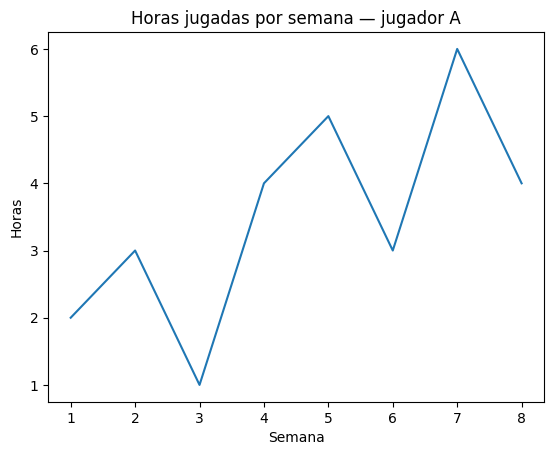

In [2]:
horas_por_semana_jugadorA = [2, 3, 1, 4, 5, 3, 6, 4]
semanas = list(range(1, len(horas_por_semana_jugadorA) + 1))

plt.plot(semanas, horas_por_semana_jugadorA)
plt.title("Horas jugadas por semana — jugador A")
plt.xlabel("Semana")
plt.ylabel("Horas")
plt.show()

### Personalización: varias líneas, colores, marcadores, leyenda y grid

Comparar dos series en la misma gráfica es mucho más útil que verlas por separado.

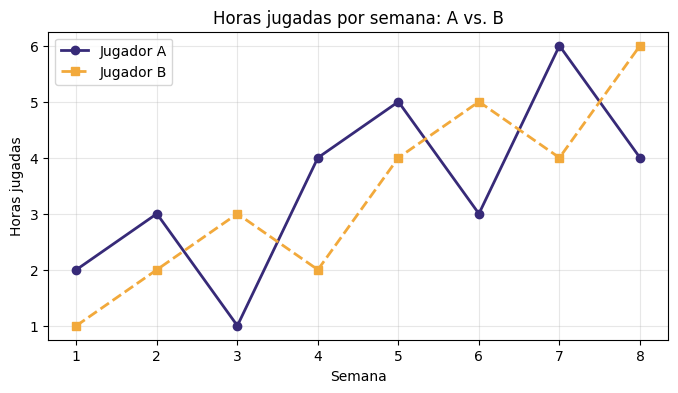

In [3]:
horas_jugadorB = [1, 2, 3, 2, 4, 5, 4, 6]

plt.figure(figsize=(8, 4))
plt.plot(semanas, horas_por_semana_jugadorA, color="#372A78", marker="o", linewidth=2, label="Jugador A")
plt.plot(semanas, horas_jugadorB, color="#F2A93B", marker="s", linewidth=2, linestyle="--", label="Jugador B")

plt.title("Horas jugadas por semana: A vs. B")
plt.xlabel("Semana")
plt.ylabel("Horas jugadas")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Ejercicio:** tienes los minutos vistos de una serie en una plataforma de streaming a lo largo de 8 semanas. Dibuja tú la línea, con título, etiquetas en los ejes y marcador en cada punto — sin mirar la solución.

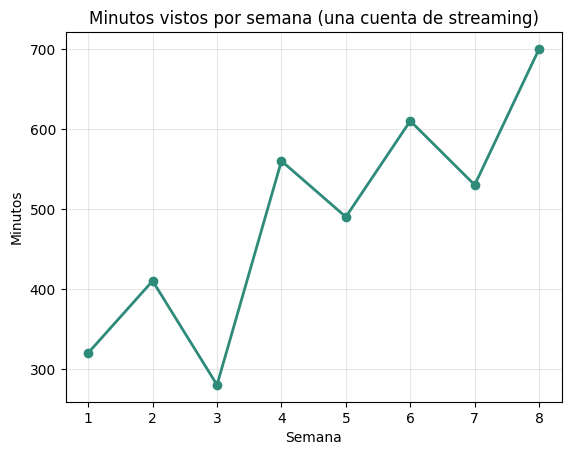

In [4]:
# Solución del ejercicio
minutos_netflix = [320, 410, 280, 560, 490, 610, 530, 700]

plt.plot(semanas, minutos_netflix, color="#2E8B7A", marker="o", linewidth=2)
plt.title("Minutos vistos por semana (una cuenta de streaming)")
plt.xlabel("Semana")
plt.ylabel("Minutos")
plt.grid(alpha=0.3)
plt.show()

## 2 · Gráfico de barras: comparar categorías

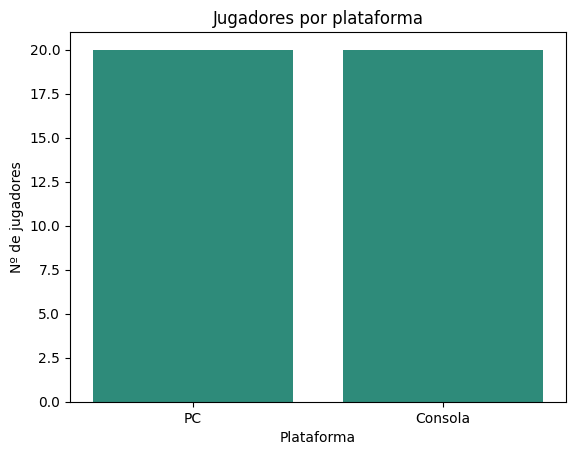

In [5]:
conteo_plataforma = df_limpio["plataforma"].value_counts()

plt.bar(conteo_plataforma.index, conteo_plataforma.values, color="#2E8B7A")
plt.title("Jugadores por plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Nº de jugadores")
plt.show()

### Barras horizontales, y barras agrupadas para dos series

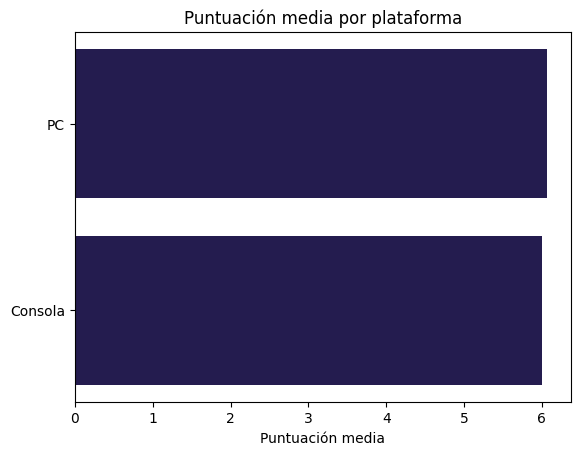

In [6]:
puntuacion_media_por_plataforma = df_limpio.groupby("plataforma")["puntuacion"].mean()

plt.barh(puntuacion_media_por_plataforma.index, puntuacion_media_por_plataforma.values, color="#241C4F")
plt.title("Puntuación media por plataforma")
plt.xlabel("Puntuación media")
plt.show()

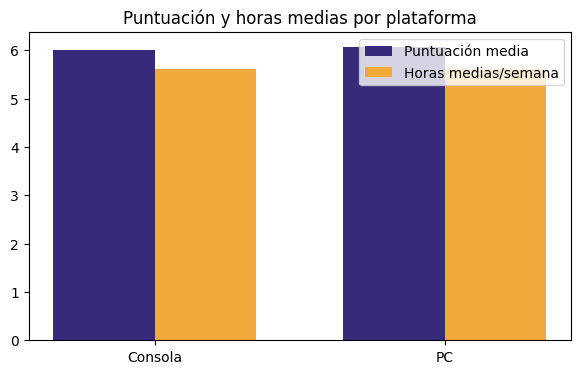

In [7]:
# Barras agrupadas: comparar dos métricas lado a lado por categoría
resumen = df_limpio.groupby("plataforma").agg(
    puntuacion_media=("puntuacion", "mean"),
    horas_media=("horas_jugadas", "mean"),
)

x = np.arange(len(resumen))
ancho = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - ancho/2, resumen["puntuacion_media"], ancho, label="Puntuación media", color="#372A78")
ax.bar(x + ancho/2, resumen["horas_media"], ancho, label="Horas medias/semana", color="#F2A93B")

ax.set_xticks(x)
ax.set_xticklabels(resumen.index)
ax.set_title("Puntuación y horas medias por plataforma")
ax.legend()
plt.show()

### Cada barra de un color distinto, y ticks personalizados

A veces quieres destacar una barra sobre las demás, o cambiar las etiquetas de un eje para que se lean en "miles" en vez de con todos los ceros.

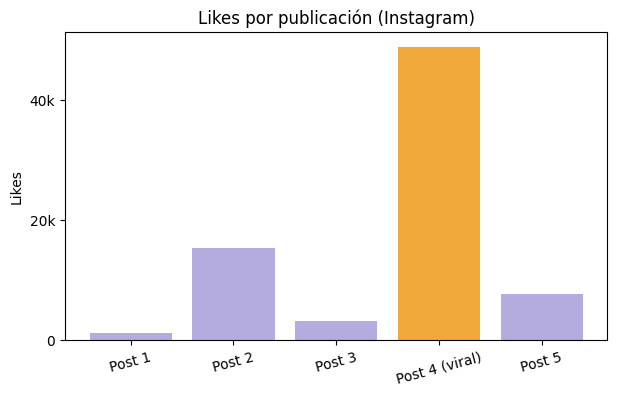

In [8]:
likes_por_publicacion = pd.Series(
    [1200, 15400, 3200, 48900, 7600],
    index=["Post 1", "Post 2", "Post 3", "Post 4 (viral)", "Post 5"],
)

colores_barras = ["#B4ABDE", "#B4ABDE", "#B4ABDE", "#F2A93B", "#B4ABDE"]   # destacamos la publicación viral

plt.figure(figsize=(7, 4))
plt.bar(likes_por_publicacion.index, likes_por_publicacion.values, color=colores_barras)
plt.title("Likes por publicación (Instagram)")
plt.ylabel("Likes")

# ticks personalizados: mostramos "0", "20k", "40k" en vez de "0", "20000", "40000"
plt.yticks([0, 20000, 40000], ["0", "20k", "40k"])
plt.xticks(rotation=15)
plt.show()

## 3 · Histograma: cómo se distribuye una variable numérica

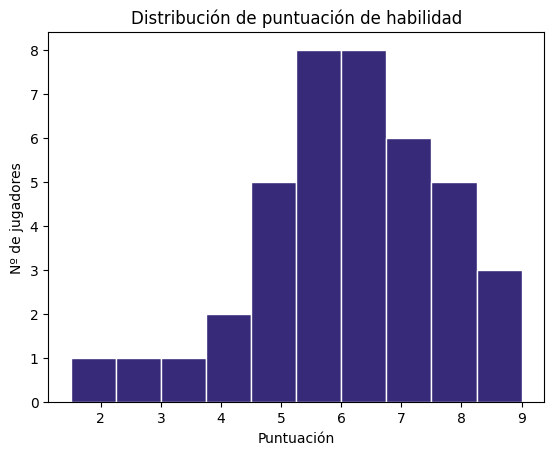

In [9]:
plt.hist(df_limpio["puntuacion"], bins=10, color="#372A78", edgecolor="white")
plt.title("Distribución de puntuación de habilidad")
plt.xlabel("Puntuación")
plt.ylabel("Nº de jugadores")
plt.show()

### El número de bins cambia mucho lo que "ves" — pruébalo

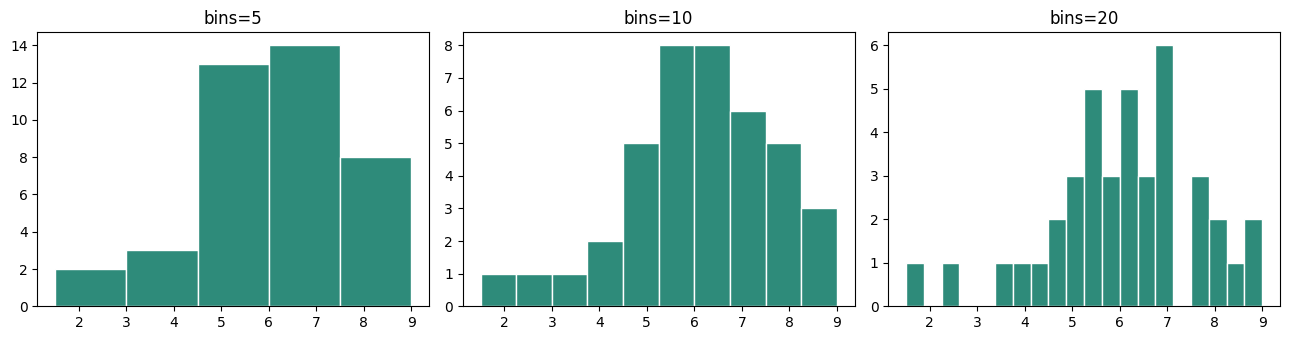

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

for ax, n_bins in zip(axes, [5, 10, 20]):
    ax.hist(df_limpio["puntuacion"], bins=n_bins, color="#2E8B7A", edgecolor="white")
    ax.set_title(f"bins={n_bins}")

plt.tight_layout()
plt.show()

## 4 · Diagrama de dispersión: relación entre dos variables

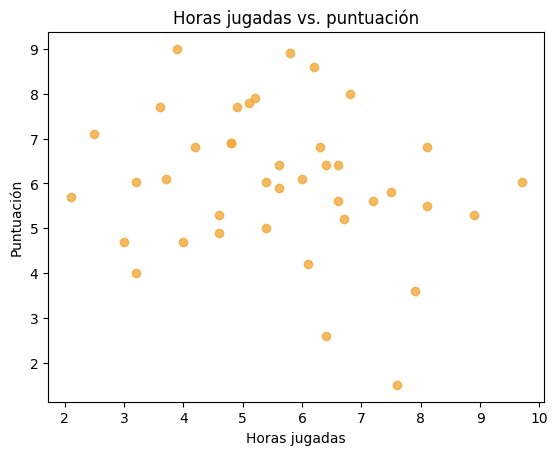

In [11]:
plt.scatter(df_limpio["horas_jugadas"], df_limpio["puntuacion"], color="#F2A93B", alpha=0.8)
plt.title("Horas jugadas vs. puntuación")
plt.xlabel("Horas jugadas")
plt.ylabel("Puntuación")
plt.show()

### Añadir una tercera variable con color

Si coloreamos cada punto según una categoría, el scatter cuenta una historia con tres variables a la vez, no solo dos.

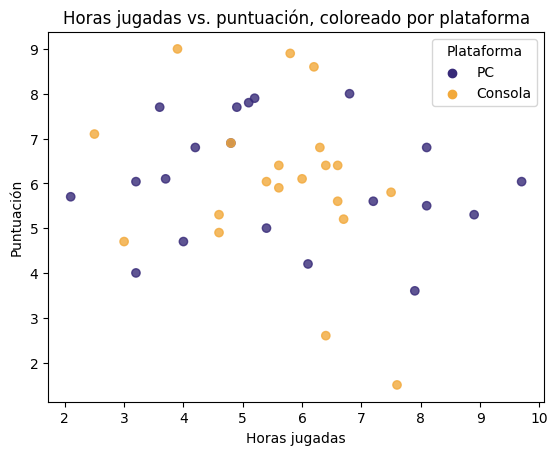

In [12]:
colores = df_limpio["plataforma"].map({"PC": "#372A78", "Consola": "#F2A93B"})

plt.scatter(df_limpio["horas_jugadas"], df_limpio["puntuacion"], c=colores, alpha=0.8)
plt.title("Horas jugadas vs. puntuación, coloreado por plataforma")
plt.xlabel("Horas jugadas")
plt.ylabel("Puntuación")

# leyenda manual, porque scatter con "c" no genera leyenda automáticamente
for plataforma, color in {"PC": "#372A78", "Consola": "#F2A93B"}.items():
    plt.scatter([], [], color=color, label=plataforma)
plt.legend(title="Plataforma")
plt.show()

## 5 · Boxplot: comparar la distribución completa entre grupos

El boxplot resume mediana, cuartiles y valores extremos ("outliers") de un vistazo — más informativo que comparar solo medias.

/tmp/ipykernel_1565/2520747521.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grupos, labels=df_limpio["plataforma"].unique())


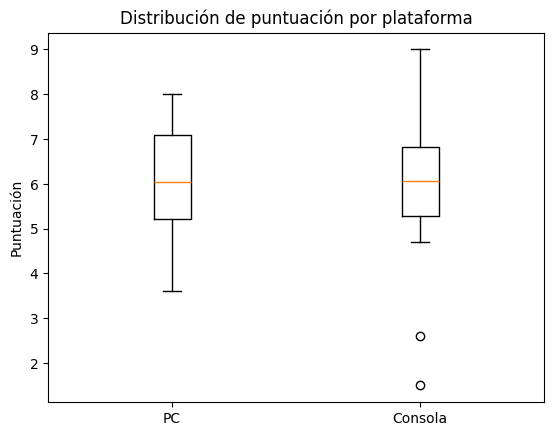

In [13]:
grupos = [df_limpio[df_limpio["plataforma"] == p]["puntuacion"] for p in df_limpio["plataforma"].unique()]

plt.boxplot(grupos, labels=df_limpio["plataforma"].unique())
plt.title("Distribución de puntuación por plataforma")
plt.ylabel("Puntuación")
plt.show()

## 6 · Gráfico de pastel (pie chart): reparto de un total

El pie chart solo tiene sentido cuando las partes suman un todo con significado (por ejemplo, cuota de mercado o reparto de tiempo) — con muchas categorías parecidas se vuelve ilegible, así que úsalo con moderación.

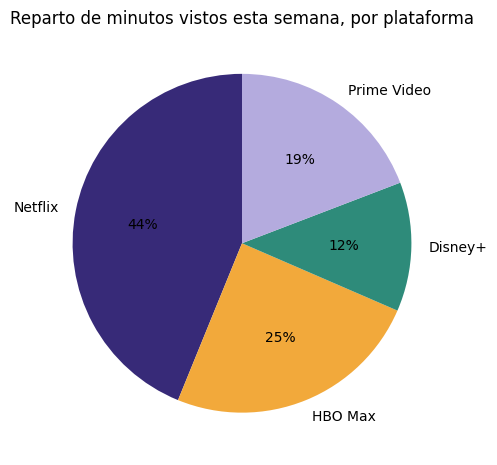

In [14]:
minutos_streaming_semana = {
    "Netflix": 320,
    "HBO Max": 180,
    "Disney+": 90,
    "Prime Video": 140,
}

plt.figure(figsize=(5.5, 5.5))
plt.pie(
    minutos_streaming_semana.values(),
    labels=minutos_streaming_semana.keys(),
    autopct="%1.0f%%",                      # muestra el porcentaje de cada porción
    colors=["#372A78", "#F2A93B", "#2E8B7A", "#B4ABDE"],
    startangle=90,
)
plt.title("Reparto de minutos vistos esta semana, por plataforma")
plt.show()

## 7 · Subplots: varias gráficas en una sola figura

/tmp/ipykernel_1565/3961834102.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(grupos, labels=df_limpio["plataforma"].unique())


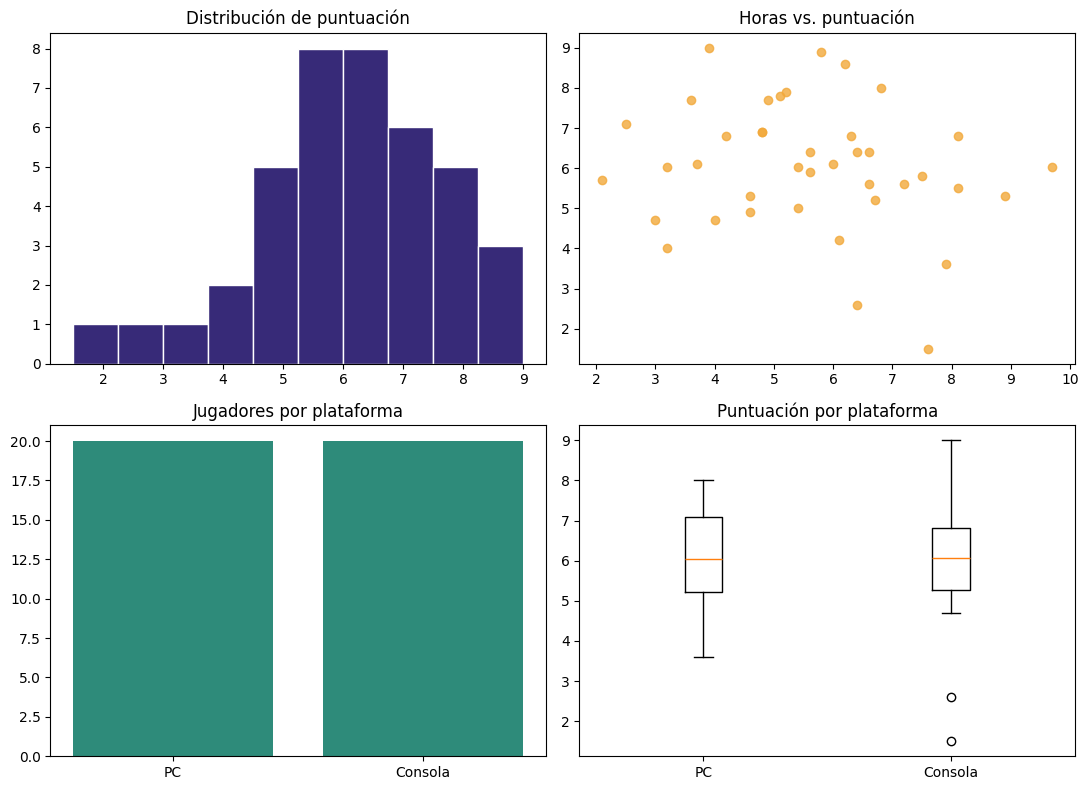

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].hist(df_limpio["puntuacion"], bins=10, color="#372A78", edgecolor="white")
axes[0, 0].set_title("Distribución de puntuación")

axes[0, 1].scatter(df_limpio["horas_jugadas"], df_limpio["puntuacion"], color="#F2A93B", alpha=0.8)
axes[0, 1].set_title("Horas vs. puntuación")

conteo = df_limpio["plataforma"].value_counts()
axes[1, 0].bar(conteo.index, conteo.values, color="#2E8B7A")
axes[1, 0].set_title("Jugadores por plataforma")

axes[1, 1].boxplot(grupos, labels=df_limpio["plataforma"].unique())
axes[1, 1].set_title("Puntuación por plataforma")

plt.tight_layout()
plt.show()

## 8 · Estilos predefinidos: plt.style.use()

Matplotlib trae paletas de estilo completas (colores, fondo, rejilla...) listas para usar, útiles para dar un aspecto distinto sin personalizar cada detalle a mano.

Algunos estilos disponibles: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic'] ...


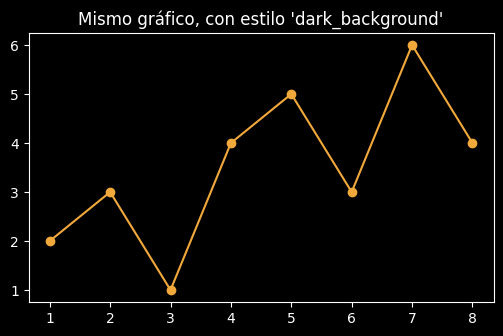

In [16]:
print("Algunos estilos disponibles:", plt.style.available[:6], "...")

plt.style.use("dark_background")
plt.figure(figsize=(6, 3.5))
plt.plot(semanas, horas_por_semana_jugadorA, color="#F2A93B", marker="o")
plt.title("Mismo gráfico, con estilo 'dark_background'")
plt.show()

plt.style.use("default")   # volvemos al estilo normal para el resto del cuaderno

## 9 · El atajo que verás en casi todo el código real: graficar directamente desde Pandas

Un DataFrame o una Series tienen su propio método `.plot()`, que por debajo usa Matplotlib — útil cuando quieres algo rápido sin escribir tres líneas de configuración.

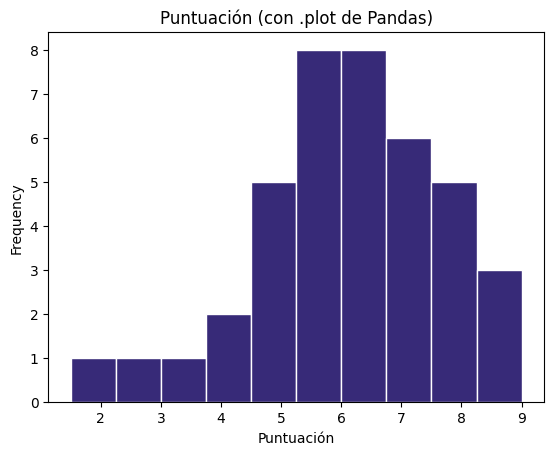

In [17]:
df_limpio["puntuacion"].plot(kind="hist", bins=10, color="#372A78", edgecolor="white", title="Puntuación (con .plot de Pandas)")
plt.xlabel("Puntuación")
plt.show()

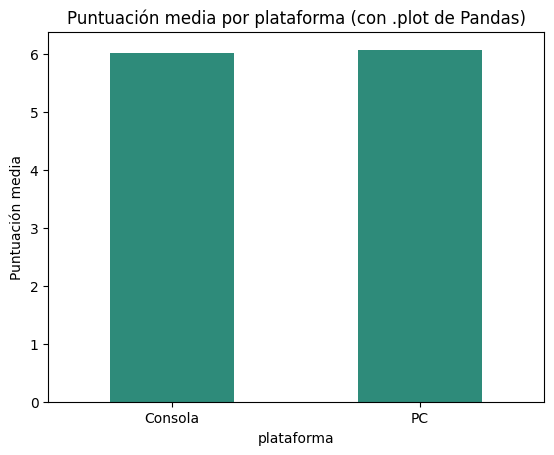

In [18]:
df_limpio.groupby("plataforma")["puntuacion"].mean().plot(
    kind="bar", color="#2E8B7A", title="Puntuación media por plataforma (con .plot de Pandas)"
)
plt.ylabel("Puntuación media")
plt.xticks(rotation=0)
plt.show()

## 10 · Guardar una figura en un archivo

Para incluir una gráfica en una memoria, presentación o informe, se guarda con `savefig` — hazlo ANTES de `plt.show()`, porque `show()` puede "vaciar" la figura en algunos entornos.

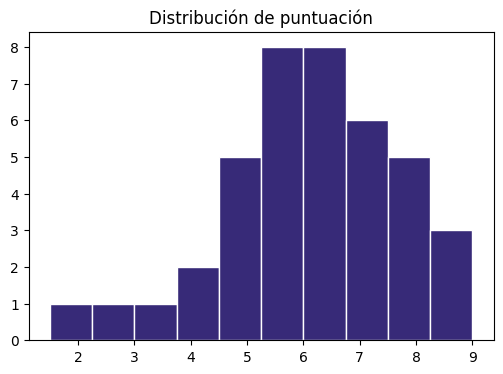

Gráfica guardada como distribucion_puntuacion.png


In [19]:
plt.figure(figsize=(6, 4))
plt.hist(df_limpio["puntuacion"], bins=10, color="#372A78", edgecolor="white")
plt.title("Distribución de puntuación")
plt.savefig("distribucion_puntuacion.png", dpi=120, bbox_inches="tight")
plt.show()

print("Gráfica guardada como distribucion_puntuacion.png")

## 11 · Reto rápido

Construye tú una gráfica que responda a esta pregunta: **¿hay más dispersión en las horas jugadas en PC o en Consola?** Pista: un boxplot de `horas_jugadas`, agrupado por `plataforma`, es la herramienta más directa para esto — no falta ni le sobra nada del código de la sección 5.

/tmp/ipykernel_1565/362111564.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grupos_horas, labels=df_limpio["plataforma"].unique())


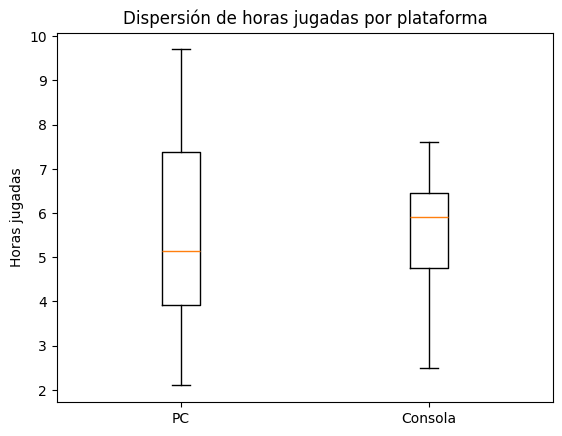

In [20]:
# Solución del reto
grupos_horas = [df_limpio[df_limpio["plataforma"] == p]["horas_jugadas"] for p in df_limpio["plataforma"].unique()]

plt.boxplot(grupos_horas, labels=df_limpio["plataforma"].unique())
plt.title("Dispersión de horas jugadas por plataforma")
plt.ylabel("Horas jugadas")
plt.show()

---
**Resumen de lo practicado:** líneas (con varias series y personalización) · barras (verticales, horizontales, agrupadas, con colores y ticks personalizados) · histogramas (y el efecto de `bins`) · scatter (incluyendo una tercera variable con color) · boxplot · gráfico de pastel · subplots en cuadrícula · estilos predefinidos con `plt.style.use()` · graficar directamente desde Pandas con `.plot()` · guardar figuras con `savefig`.

**Siguiente cuaderno:** `UT2_04_reto_integrador.ipynb`, donde combinamos NumPy + Pandas + Matplotlib y damos un primer vistazo a Scikit-learn.